### Libs

In [1]:
import numpy as np
import math as math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


### Данные

In [2]:
df = pd.read_csv('train.csv')

In [ ]:
# Кодируем текстовые столбцы в числа
df_encoded = pd.get_dummies(df, drop_first=True)  # One-Hot Encoding
# Теперь пересобираем X
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
X = df_encoded[numeric_cols].drop(columns=["SalePrice", "Id"])

X = X.fillna(X.median())
y = np.log1p(df["SalePrice"])

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
from sklearn.pipeline import Pipeline


model = XGBRegressor(n_estimators=1000,
                            learning_rate=0.05,
                            max_depth=6,
                            random_state=42,
                            n_jobs=-1
                            )

param_grid = {
    "n_estimators": [50, 100, 200,1000],
    "max_depth":    [None, 5, 10],
}

In [29]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid.fit(X_train, y_train)


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'max_depth': [None, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [30]:
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучший RMSE: {-grid.best_score_:.4f}")

Лучшие параметры: {'max_depth': 5, 'n_estimators': 100}
Лучший RMSE: 0.1566


In [31]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50   # остановиться если 50 итераций без улучшения
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=100)

print(f"Лучшее количество деревьев: {model.best_iteration}")
print(model.score(X_test,y_test))

[0]	validation_0-rmse:0.41777
[100]	validation_0-rmse:0.16913
[130]	validation_0-rmse:0.16933
Лучшее количество деревьев: 80
0.8472219736284876


### поиск клаасных фич

In [ ]:
# Установить в терминале
# pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Скачиваем данные Apple за 5 лет
df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

print(df.shape)
print(df.head())
#             Open    High     Low   Close    Volume
# 2019-01-02  154.0  158.0  154.0   157.0  37039700

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [19]:
corr = df.select_dtypes(include=[np.number]).corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(11))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


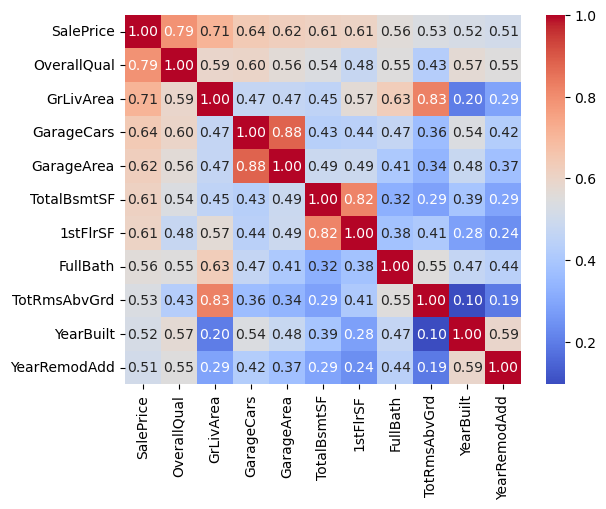

In [20]:
top_features = corr.head(11).index
sns.heatmap(df[top_features].corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.show()


### trading

In [17]:
# Установить в терминале
# pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Скачиваем данные Apple за 5 лет
df = yf.download("BTC-USD", start="2019-01-01", end="2024-01-01")
df.columns = df.columns.droplevel(1) 
print(df.shape)
print(df.head())
#             Open    High     Low   Close    Volume
# 2019-01-02  154.0  158.0  154.0   157.0  37039700

[*********************100%***********************]  1 of 1 completed

(1826, 5)
Price             Close         High          Low         Open      Volume
Date                                                                      
2019-01-01  3843.520020  3850.913818  3707.231201  3746.713379  4324200990
2019-01-02  3943.409424  3947.981201  3817.409424  3849.216309  5244856836
2019-01-03  3836.741211  3935.685059  3826.222900  3931.048584  4530215219
2019-01-04  3857.717529  3865.934570  3783.853760  3832.040039  4847965467
2019-01-05  3845.194580  3904.903076  3836.900146  3851.973877  5137609824


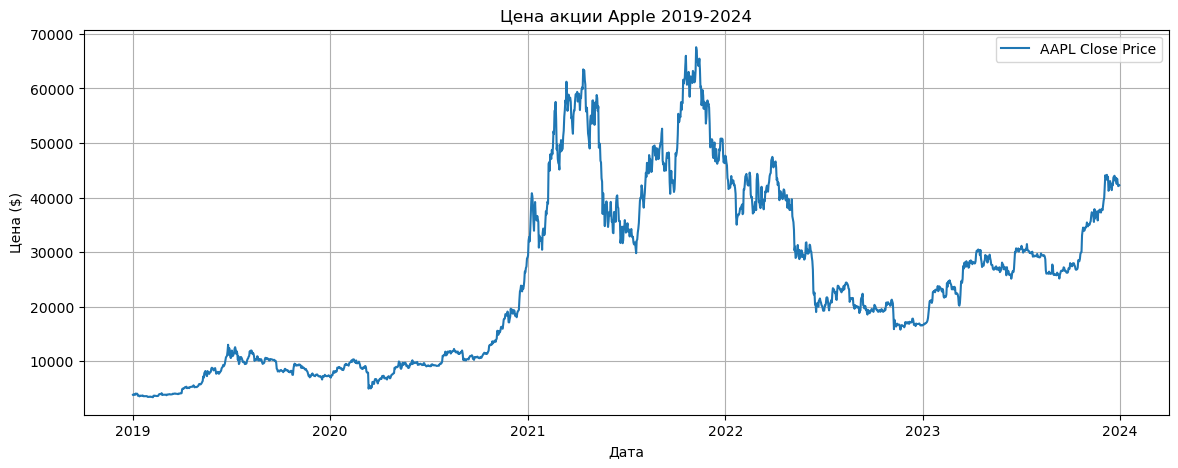

Price         Close          High           Low          Open        Volume
count   1826.000000   1826.000000   1826.000000   1826.000000  1.826000e+03
mean   24593.766878  25132.683570  23978.199624  24574.914299  2.903692e+10
std    16064.683022  16477.576869  15600.213992  16071.008463  1.814585e+10
min     3399.471680   3427.945557   3391.023682   3401.376465  4.324201e+09
25%     9672.332764   9835.049561   9512.193848   9667.602051  1.711804e+10
50%    22185.371094  22598.989258  21453.022461  22013.654297  2.578971e+10
75%    36793.921875  37640.723633  35383.756836  36701.667969  3.628123e+10
max    67566.828125  68789.625000  66382.062500  67549.734375  3.509679e+11


In [18]:
# Визуализируем цену закрытия
plt.figure(figsize=(14, 5))
plt.plot(df["Close"], label="AAPL Close Price")
plt.title("Цена акции Apple 2019-2024")
plt.xlabel("Дата")
plt.ylabel("Цена ($)")
plt.legend()
plt.grid(True)
plt.show()

print(df.describe())

In [19]:
# Скользящие средние — тренд
df["MA_7"]  = df["Close"].rolling(window=7).mean()   # 7 дней
df["MA_21"] = df["Close"].rolling(window=21).mean()  # 21 день
df["MA_50"] = df["Close"].rolling(window=50).mean()  # 50 дней

# Волатильность — насколько сильно цена колеблется
df["Volatility"] = df["Close"].rolling(window=21).std()

# Дневной возврат — изменение цены за день в %
df["Daily_Return"] = df["Close"].pct_change()

# RSI — индикатор перекупленности/перепроданности (0-100)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window=period).mean()
    loss  = (-delta.clip(upper=0)).rolling(window=period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df["RSI"] = compute_rsi(df["Close"])

# MACD — разница между быстрой и медленной скользящей
ema_12 = df["Close"].ewm(span=12).mean()  # экспоненциальная скользящая
ema_26 = df["Close"].ewm(span=26).mean()
df["MACD"] = ema_12 - ema_26
df["MACD_Signal"] = df["MACD"].ewm(span=9).mean()

# Объём — нормализованный
df["Volume_Change"] = df["Volume"].pct_change()

print(df.tail())

Price              Close          High           Low          Open  \
Date                                                                 
2023-12-27  43442.855469  43683.160156  42167.582031  42518.468750   
2023-12-28  42627.855469  43804.781250  42318.550781  43468.199219   
2023-12-29  42099.402344  43124.324219  41424.062500  42614.644531   
2023-12-30  42156.902344  42584.125000  41556.226562  42091.753906   
2023-12-31  42265.187500  42860.937500  41998.253906  42152.097656   

Price            Volume          MA_7         MA_21         MA_50  Volatility  \
Date                                                                            
2023-12-27  25260941032  43457.016183  42945.413690  40039.379844  911.438760   
2023-12-28  22992093014  43279.688058  42913.756138  40178.831406  910.319352   
2023-12-29  26000021055  43008.473772  42815.318080  40286.956953  879.308985   
2023-12-30  16013925945  42782.382254  42740.599888  40383.815625  864.599474   
2023-12-31  16397498810

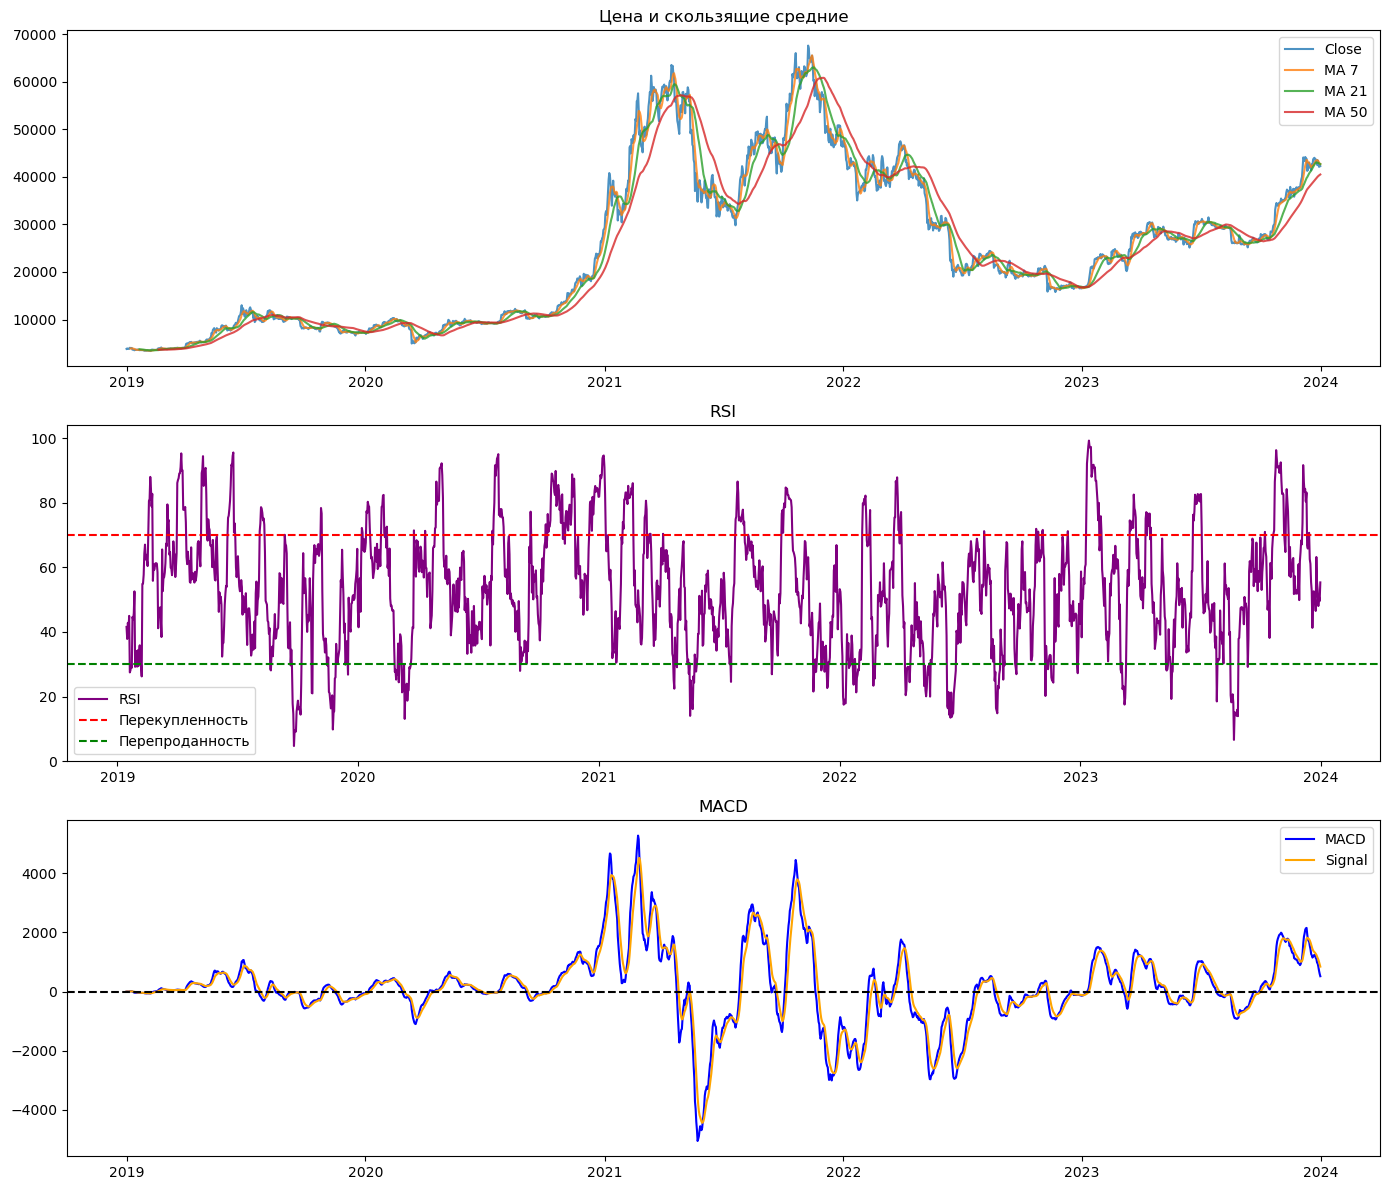

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Цена + скользящие средние
axes[0].plot(df["Close"],  label="Close",  alpha=0.8)
axes[0].plot(df["MA_7"],   label="MA 7",   alpha=0.8)
axes[0].plot(df["MA_21"],  label="MA 21",  alpha=0.8)
axes[0].plot(df["MA_50"],  label="MA 50",  alpha=0.8)
axes[0].set_title("Цена и скользящие средние")
axes[0].legend()

# RSI
axes[1].plot(df["RSI"], color="purple", label="RSI")
axes[1].axhline(70, color="red",   linestyle="--", label="Перекупленность")
axes[1].axhline(30, color="green", linestyle="--", label="Перепроданность")
axes[1].set_title("RSI")
axes[1].legend()

# MACD
axes[2].plot(df["MACD"],        label="MACD",   color="blue")
axes[2].plot(df["MACD_Signal"], label="Signal", color="orange")
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_title("MACD")
axes[2].legend()

plt.tight_layout()
plt.show()

In [21]:
# Предсказываем: вырастет ли цена завтра? (классификация)
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
# 1 = цена завтра выше сегодняшней
# 0 = цена завтра ниже сегодняшней

# Убираем строки с NaN (из-за скользящих средних)
df.dropna(inplace=True)

# Признаки и целевая переменная
features = ["MA_7", "MA_21", "MA_50", "RSI", "MACD", 
            "MACD_Signal", "Volatility", "Volume_Change", "Daily_Return"]

X = df[features]
y = df["Target"]

print(f"Размер X: {X.shape}")
print(f"Баланс классов:\n{y.value_counts()}")  # сколько дней вверх/вниз

Размер X: (1777, 9)
Баланс классов:
Target
1    909
0    868
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Важно: для временных рядов НЕ перемешиваем данные!
# shuffle=False — сохраняем временной порядок
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Сравниваем модели
models = {
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "RandomForest":     RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} — Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


GradientBoosting — Accuracy: 0.5225
              precision    recall  f1-score   support

           0       0.53      0.51      0.52       182
           1       0.51      0.53      0.52       174

    accuracy                           0.52       356
   macro avg       0.52      0.52      0.52       356
weighted avg       0.52      0.52      0.52       356


RandomForest — Accuracy: 0.5056
              precision    recall  f1-score   support

           0       0.52      0.48      0.50       182
           1       0.49      0.53      0.51       174

    accuracy                           0.51       356
   macro avg       0.51      0.51      0.51       356
weighted avg       0.51      0.51      0.51       356



In [23]:
# Добавим больше признаков
# Bollinger Bands — канал волатильности
df["BB_middle"] = df["Close"].rolling(20).mean()
df["BB_upper"]  = df["BB_middle"] + 2 * df["Close"].rolling(20).std()
df["BB_lower"]  = df["BB_middle"] - 2 * df["Close"].rolling(20).std()
df["BB_width"]  = (df["BB_upper"] - df["BB_lower"]) / df["BB_middle"]  # ширина канала
df["BB_pos"]    = (df["Close"] - df["BB_lower"]) / (df["BB_upper"] - df["BB_lower"])  # позиция цены внутри канала

# Momentum — сила тренда
df["Momentum_7"]  = df["Close"] / df["Close"].shift(7)  - 1
df["Momentum_21"] = df["Close"] / df["Close"].shift(21) - 1

# Соотношение объёма к скользящей средней
df["Volume_MA"]    = df["Volume"].rolling(21).mean()
df["Volume_Ratio"] = df["Volume"] / df["Volume_MA"]  # > 1 значит объём выше среднего

# Обновляем список признаков
features = [
    "MA_7", "MA_21", "MA_50",
    "RSI", "MACD", "MACD_Signal",
    "Volatility", "Volume_Change", "Daily_Return",
    "BB_width", "BB_pos",          # новые
    "Momentum_7", "Momentum_21",   # новые
    "Volume_Ratio"                 # новый
]

In [25]:
# Обычный train/test не учитывает что рынок меняется со временем
# Walk Forward — обучаемся на прошлом, проверяем на будущем, сдвигаемся вперёд

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
accuracies = []

model = GradientBoostingClassifier(n_estimators=200, 
                                    learning_rate=0.05,
                                    max_depth=4,
                                    random_state=42)

X_arr = X.values
y_arr = y.values

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_arr)):
    X_tr, X_te = X_arr[train_idx], X_arr[test_idx]
    y_tr, y_te = y_arr[train_idx], y_arr[test_idx]
    
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)
    
    model.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te))
    accuracies.append(acc)
    print(f"Fold {fold+1}: {acc:.4f}")


Fold 1: 0.5203
Fold 2: 0.4595
Fold 3: 0.5642
Fold 4: 0.4662
Fold 5: 0.5304


In [ ]:

ss=1
i = 1
while(ss*i < 10**8):
    ss*=i
    i+=1
print(i)

12
